In [ ]:
import arviz as az
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import preliz as pz
import bambi as bmb

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning, module='pytensor')

SEED = 12

az.style.use("arviz-doc")

# Parte 3: Procesos Gaussianos (GPs)

En esta sección realizamos una breve exploración del uso de **Procesos Gaussianos** para modelar relaciones continuas.
Tomaremos como ejemplo los datos de ventas de una pizzería utilizados en la Parte 1, y modelaremos la cantidad de ventas por hora.

El objetivo es visualizar cómo el modelo captura la **tendencia** y la **incertidumbre** de las predicciones. 

In [2]:
pizza = pd.read_csv('../data/pizza_sales.csv', index_col=0)

In [3]:
pizza['order_hour'] = pd.to_datetime(pizza['order_time'], format='%H:%M:%S').dt.hour
pizza['order_date'] = pd.to_datetime(pizza['order_date'], format='%m/%d/%Y')

Nos quedamos con las ventas hechas en Junio para reducir la cantidad de datos.

In [4]:
pizza.query('order_date >= "2015-06-01" & order_date < "2015-07-01"', inplace=True)

In [5]:
conteo = pizza.groupby(['order_date', 'order_hour']).size().reset_index(name='sales')

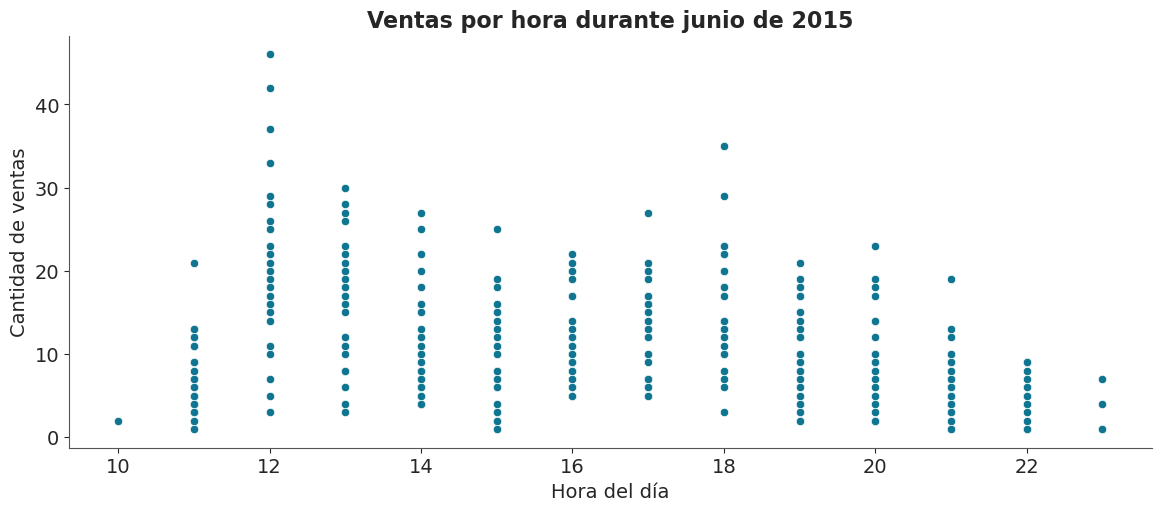

In [39]:
sns.scatterplot(data=conteo, x='order_hour', y='sales')
plt.title('Ventas por hora durante junio de 2015')
plt.xlabel('Hora del día')
plt.ylabel('Cantidad de ventas');

## Definición del modelo
 
Usaremos un **Proceso Gaussiano en Espacios de Hilbert (HSGP)** para modelar la relación entre la hora del día y la cantidad de ventas.
 
Este tipo de modelo es flexible y permite capturar patrones no lineales sin definir una forma funcional explícita.

In [7]:
def get_ig_params(x_vals, l_b=None, u_b=None, mass=0.95, plot=False):
    """
    Returns a weakly informative prior for the length-scale parameter of the GP kernel.
    """

    differences = np.abs(np.subtract.outer(x_vals, x_vals))
    if l_b is None:
        l_b = np.min(differences[differences != 0]) * 2
    if u_b is None:
        u_b = np.max(differences) / 1.5

    dist = pz.InverseGamma()
    pz.maxent(dist, l_b, u_b, mass, plot=plot)

    return dict(zip(dist.param_names, dist.params))

Definimos los **priors** para los hiperparámetros del proceso gaussiano:
- $\sigma$: controla la varianza de la función.
- $\ell$: controla la suavidad (longitud de correlación).
 
Además, agregamos un parámetro $\alpha$ que controla la dispersión del modelo de conteos (distribución Binomial Negativa).

In [27]:
prior_gp = {
    "sigma": bmb.Prior("Gamma", mu=1, sigma=0.01),
    "ell": bmb.Prior("InverseGamma", **get_ig_params(conteo[['order_hour']].values)) 
}

priors = {
    "hsgp(order_hour, m=10, c=1.5)": prior_gp,
    "alpha": bmb.Prior("HalfNormal", sigma=1)
}

Ajustamos el modelo usando la familia **Binomial Negativa**, adecuada para datos de conteo con sobredispersión.

In [28]:
model_hsb = bmb.Model("sales ~ 0 + hsgp(order_hour, m=10, c=1.5)", conteo, 
                      family="negativebinomial", 
                      priors=priors)

idata_hsb = model_hsb.fit(random_seed=SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, hsgp(order_hour, m=10, c=1.5)_sigma, hsgp(order_hour, m=10, c=1.5)_ell, hsgp(order_hour, m=10, c=1.5)_weights_raw]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 117 seconds.


## Resultados del muestreo
 
Observamos las distribuciones posteriores de los parámetros del proceso gaussiano y del parámetro de dispersión.

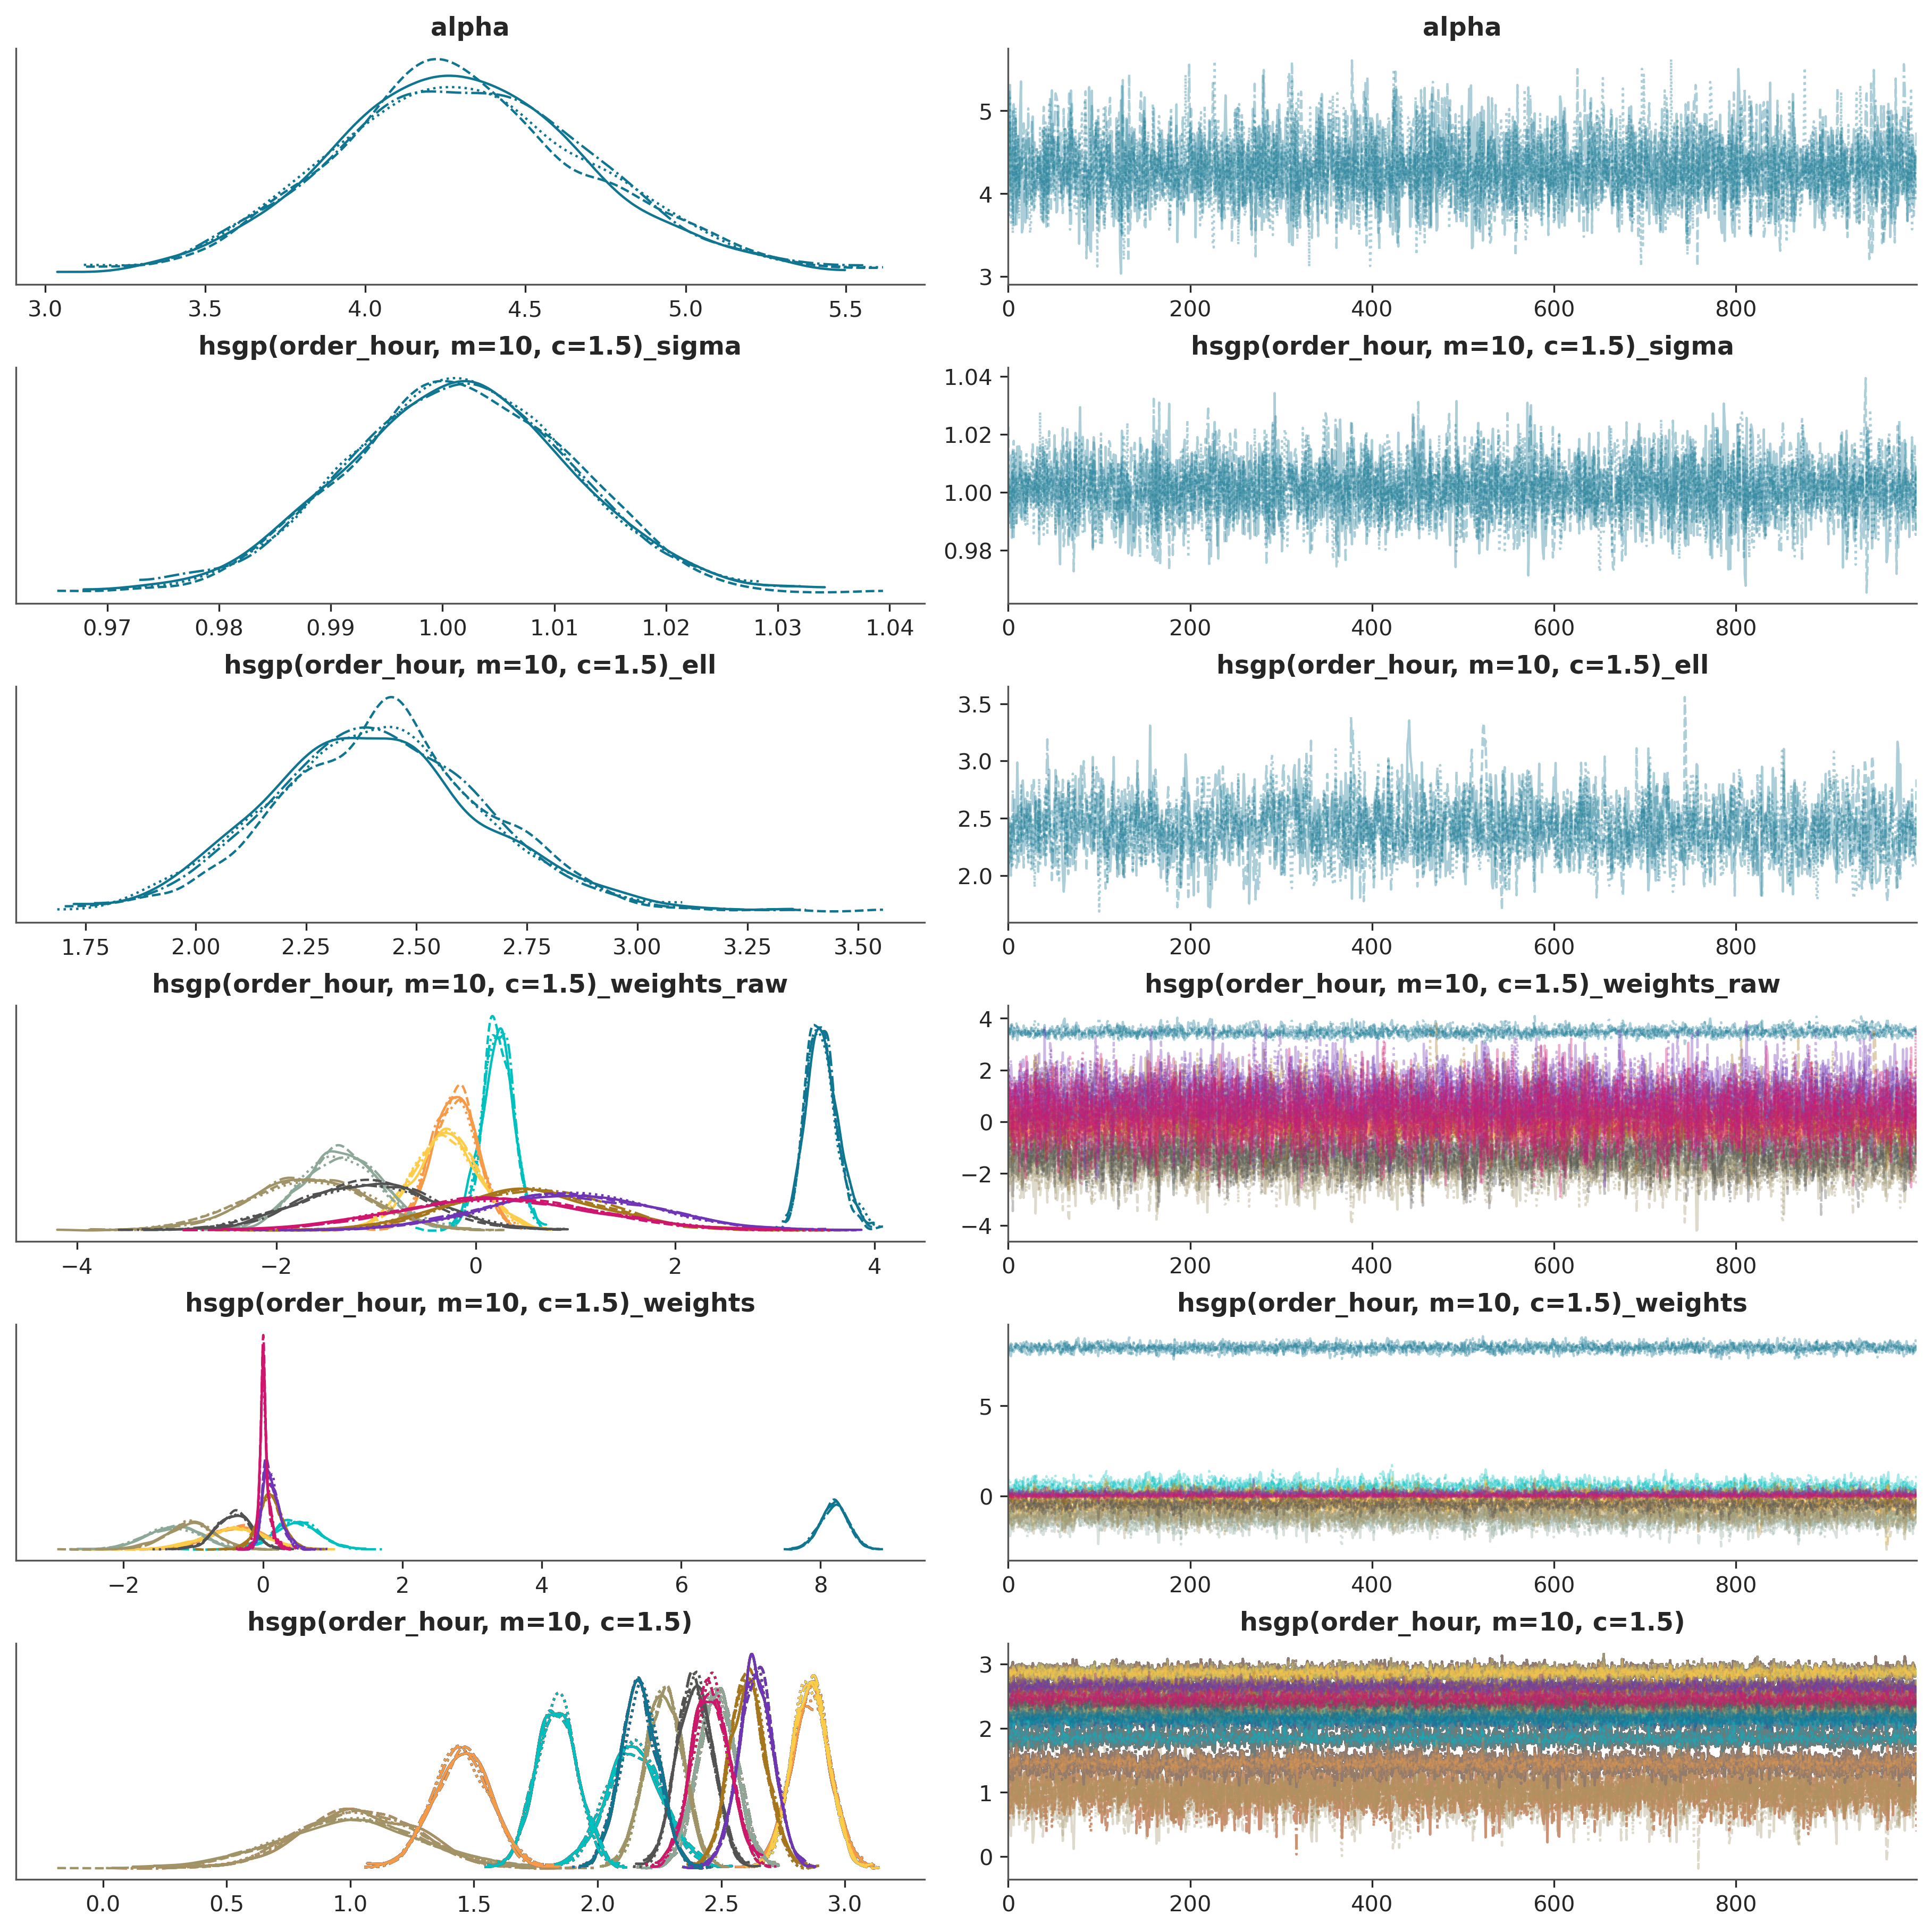

In [29]:
az.plot_trace(idata_hsb);

## Predicciones y visualización

A continuación generamos las predicciones del modelo y visualizamos cómo captura la tendencia de las ventas por hora, junto con la incertidumbre.

In [30]:
model_hsb.predict(idata_hsb, kind='response', data=conteo)

Default computed for conditional variable: order_hour
Default computed for conditional variable: order_hour


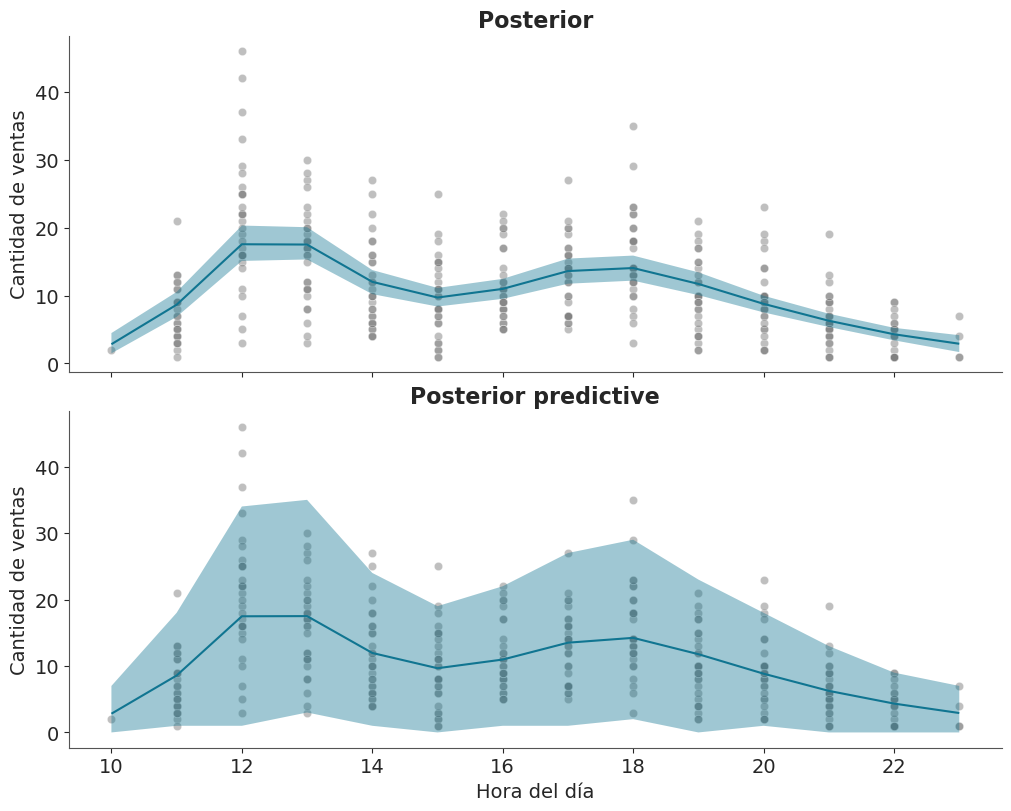

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

sns.scatterplot(data=conteo, x='order_hour', y='sales', color='grey', alpha=0.5, ax=axes[0])
bmb.interpret.plot_predictions(model_hsb, idata_hsb, 'order_hour', ax=axes[0])
axes[0].set_title('Posterior')
axes[0].set_ylabel('Cantidad de ventas')

sns.scatterplot(data=conteo, x='order_hour', y='sales', color='grey', alpha=0.5, ax=axes[1])
bmb.interpret.plot_predictions(model_hsb, idata_hsb, 'order_hour', pps=True, ax=axes[1]);
axes[1].set_title('Posterior predictive')
axes[1].set_xlabel('Hora del día')
axes[1].set_ylabel('Cantidad de ventas');

## Conclusión

El modelo con **Proceso Gaussiano** logra capturar la tendencia general de las ventas según la hora del día de manera flexible, similar a los splines.
 
Aunque el ajuste no busca ser exhaustivo, este ejemplo ilustra el potencial de los GPs para modelar relaciones continuas de forma no paramétrica y flexible.